# Get To Know A Dataset: OVRO LWA Solar Observation

This notebook is a draft guided tour of the OVRO LWA Solar Observation dataset for the Registry of Open Data on AWS. It follows the AWS Open Data Sponsorship Program tutorial template described in section 2.3 of the onboarding handbook.

The AWS bucket has not been created yet. Cells that access S3 use placeholders for the bucket name and sample object key. Once the bucket exists, replace those placeholders and rerun the notebook.

## Q: How have you organized your dataset? Help us understand the key prefix structure of your S3 bucket.

The OVRO LWA Solar Observation dataset contains low-frequency solar radio products from the Owens Valley Radio Observatory Long Wavelength Array. The release is expected to contain long-term solar observing products derived from beamformed spectroscopy and interferometric imaging.

The S3 bucket is organized into a few top-level data folders. Image products are partitioned by observation date using `YYYY/MM/DD` prefixes, while all-day spectrogram products and spectrogram quicklook images are grouped by product family. A draft layout is:

```text
s3://REPLACE-WITH-BUCKET-NAME/
  image_hdf/YYYY/MM/DD/filename
  image_png/YYYY/MM/DD/filename
  spec_fits/filename
  spec_daily_png/filename
  spec_hourly_png/filename
  docs/
```

The main product groups are:

- `image_hdf`: standard interferometric spectral image products in HDF format, including band-averaged image products such as `mfs` and fine-channel image products such as `fch`.
- `image_png`: quicklook PNG renderings of spectral image products, using the same date-based organization as `image_hdf`.
- `spec_fits`: all-day total-power spectrogram products in FITS format.
- `spec_daily_png`: daily spectrogram quicklook PNG images.
- `spec_hourly_png`: hourly spectrogram quicklook PNG images.
- `docs`: documentation and supporting metadata.

Representative file naming conventions are shown in the figures below and include:

- `ovro-lwa-352.lev1_mfs_10s.YYYY-MM-DDTHHMMSSZ.image_I.hdf`
- `ovro-lwa.lev1_bmf_256ms_96kHz.YYYY-MM-DD.dspec_I.fits`

Figure: annotated naming convention for an OVRO-LWA HDF image product.

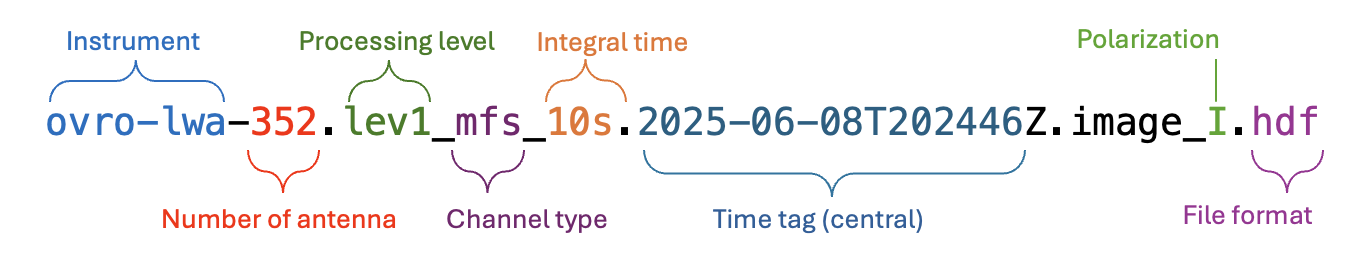

Figure: annotated naming convention for an OVRO-LWA FITS spectrogram product.

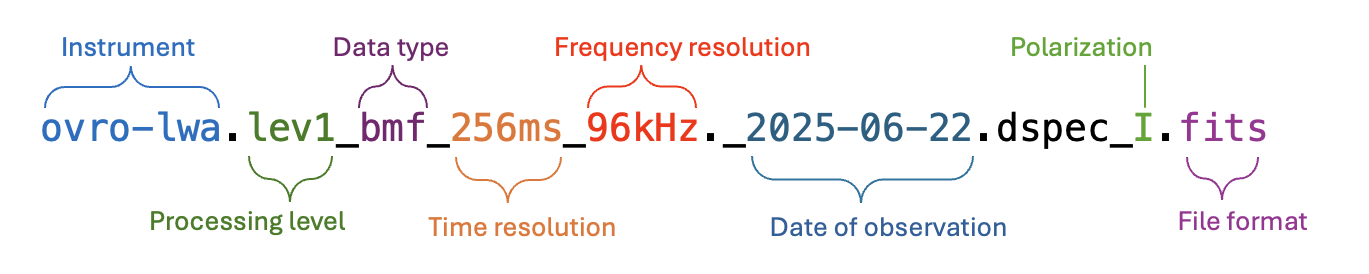

In [ ]:
# This notebook requires the following libraries:
#
# boto3>=1.34
# botocore>=1.34
# h5py>=3.10
# matplotlib>=3.8
# numpy>=1.26
#
# Optional OVRO-LWA helper package:
# git+https://github.com/ovro-eovsa/lwa-solar-util.git

from pathlib import Path
from pprint import pprint
import tempfile

import boto3
from botocore import UNSIGNED
from botocore.config import Config
import h5py
import matplotlib.pyplot as plt
import numpy as np

The following cells show the intended S3 discovery pattern. Replace `BUCKET` after the AWS Open Data bucket is created.

In [ ]:
BUCKET = "REPLACE-WITH-BUCKET-NAME"
SAMPLE_HDF_KEY = "REPLACE-WITH-SAMPLE-HDF-KEY"

s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

def bucket_is_configured(bucket):
    return bucket and not bucket.startswith("REPLACE-")

In [ ]:
if bucket_is_configured(BUCKET):
    response = s3.list_objects_v2(Bucket=BUCKET, Delimiter="/", MaxKeys=100)
    for prefix in response.get("CommonPrefixes", []):
        print(prefix["Prefix"])
else:
    print("Draft notebook: set BUCKET to list the top-level S3 prefixes.")

## Q: What data formats are present in your dataset? What kinds of data are stored using these formats? Can you give any advice for how you work with these data formats?

The data products use FITS and HDF/HDF5.

FITS is used for all-day total-power spectrogram products. The Level 1 spectrograms are standard FITS tables containing frequency, time, and Stokes I flux density in solar flux units (SFU). The Level 1.5 spectrograms add background subtraction and primary beam correction.

HDF/HDF5 is used for standard interferometric spectral images. The fine-channel image products contain independent images at 144 frequency channels spanning 32 to 87 MHz, with 10 second integrations. The band-averaged image products contain 12 multi-frequency synthesis images with center frequencies from about 34.1 to 84.6 MHz. These image products are generated in heliocentric coordinates and can be converted to FITS using the OVRO-LWA utility package.

Recommended Python tooling:

- `h5py` for generic HDF5 inspection and array loading.
- `astropy` and `sunpy` for FITS and solar-coordinate workflows.
- `matplotlib` and `numpy` for quicklook visualization.
- `lwasolarutl` for OVRO-LWA specific HDF to FITS recovery and standard plotting helpers.

## Q: Can you show us an example of downloading and loading data from your dataset?

This example downloads one HDF spectral image file from S3, opens it with `h5py`, and prints the file structure. After the bucket is created, choose a small representative band-averaged HDF file for `SAMPLE_HDF_KEY`, for example a file matching `ovro-lwa-352.lev1_mfs_10s.*.image_I.hdf`.

In [ ]:
def key_is_configured(key):
    return key and not key.startswith("REPLACE-")

if bucket_is_configured(BUCKET) and key_is_configured(SAMPLE_HDF_KEY):
    local_hdf = Path(tempfile.gettempdir()) / Path(SAMPLE_HDF_KEY).name
    s3.download_file(BUCKET, SAMPLE_HDF_KEY, str(local_hdf))
    print(f"Downloaded s3://{BUCKET}/{SAMPLE_HDF_KEY} to {local_hdf}")
else:
    local_hdf = None
    print("Draft notebook: set BUCKET and SAMPLE_HDF_KEY to download a sample HDF file.")

In [ ]:
def summarize_hdf(path, max_items=40):
    rows = []

    def visitor(name, obj):
        if len(rows) >= max_items:
            return
        if isinstance(obj, h5py.Dataset):
            rows.append({
                "path": name,
                "kind": "dataset",
                "shape": obj.shape,
                "dtype": str(obj.dtype),
            })
        elif isinstance(obj, h5py.Group):
            rows.append({"path": name, "kind": "group"})

    with h5py.File(path, "r") as handle:
        handle.visititems(visitor)
        attrs = dict(handle.attrs)

    print("File attributes:")
    pprint(attrs)
    print("\nObjects:")
    pprint(rows)

if local_hdf is not None:
    summarize_hdf(local_hdf)
else:
    print("Draft notebook: HDF inspection will run after a sample file is configured.")

## Q: A picture is worth a thousand words. Show us a visual from your dataset.

For a first visual, a user can plot one two-dimensional image plane from an HDF spectral image cube. The helper below searches the file for the first numeric dataset with at least two dimensions, selects a representative 2D plane, and renders it with percentile clipping. This generic preview is meant for orientation; science-quality plots should use the FITS recovery and solar-coordinate plotting utilities from `lwasolarutl`.

In [ ]:
def first_numeric_dataset(handle):
    found = []

    def visitor(name, obj):
        if found:
            return
        if isinstance(obj, h5py.Dataset) and obj.ndim >= 2 and np.issubdtype(obj.dtype, np.number):
            found.append(name)

    handle.visititems(visitor)
    return found[0] if found else None

def representative_2d_plane(array):
    data = np.asarray(array)
    while data.ndim > 2:
        data = data[data.shape[0] // 2]
    return data

if local_hdf is not None:
    with h5py.File(local_hdf, "r") as handle:
        dataset_name = first_numeric_dataset(handle)
        if dataset_name is None:
            raise ValueError("No numeric image-like dataset found in this HDF file.")
        image = representative_2d_plane(handle[dataset_name][...])

    vmin, vmax = np.nanpercentile(image, [1, 99])
    plt.figure(figsize=(6, 5))
    plt.imshow(image, origin="lower", cmap="inferno", vmin=vmin, vmax=vmax)
    plt.colorbar(label="Intensity")
    plt.title(f"Representative plane from {dataset_name}")
    plt.xlabel("Image x pixel")
    plt.ylabel("Image y pixel")
    plt.tight_layout()
else:
    print("Draft notebook: configure a sample HDF file to render an image plane.")

For OVRO-LWA image products, the domain-specific utility package can recover FITS from HDF and produce the standard 12-panel image layout. The existing utility notebook demonstrates the pattern:

```python
import lwasolarutl as lsu

lsu.file.recover_fits_from_h5(str(local_hdf), "recovered_from_hdf.fits")
fig, axes = lsu.visualization.slow_pipeline_default_plot("recovered_from_hdf.fits", add_logo=False)
```

This optional workflow is recommended once a representative sample file is available from the AWS bucket.

## Q: What is one question that you have answered using these data? Can you show us how you came to that answer?

One baseline question is: how does the morphology and brightness of low-frequency solar radio emission change across observing frequency during a selected time interval?

For a band-averaged spectral image product, a user can load a single `lev1_mfs_10s` or `lev1.5_mfs_10s` HDF file, recover or inspect the image planes, and compare the 12 frequency bands centered from about 34.1 to 84.6 MHz. Lower frequencies generally correspond to radio emission from higher coronal heights, while higher frequencies sample lower coronal plasma. A frequency sequence of images can therefore reveal whether emission is compact, extended, displaced by propagation effects, or associated with an active region or burst source.

A draft analysis workflow is:

1. Select a representative time range from the S3 prefix layout.
2. Load one or more band-averaged HDF image products.
3. For each frequency plane, compute summary quantities such as peak intensity, centroid position, and source area above a chosen threshold.
4. Plot those quantities versus frequency and compare them to the image panels.

This notebook contains the data-access and first-image pieces. A follow-up tutorial can turn that into a complete event-analysis workflow once public sample objects are available.

## Q: What is one unanswered question that you think could be answered using these data? Do you have any recommendations or advice for someone wanting to answer this question?

Community challenge: build an open benchmark for detecting and classifying low-frequency solar radio burst activity from OVRO-LWA spectrogram and spectral-image products.

A useful first version would combine all-day spectrograms with image-derived context. The spectrograms provide high-cadence time-frequency structure, while the HDF image products provide spatial localization and frequency-dependent morphology. A model or rules-based detector could identify candidate burst intervals, classify broad burst families, and flag intervals that deserve higher-resolution imaging or manual review.

Recommended approach:

1. Start with a small date range and build an event table with observation date, time range, frequency range, product level, and data-quality notes.
2. Use Level 1.5 products when available for background-subtracted or refraction-corrected analysis, but keep Level 1 products for cases where Level 1.5 is not applicable during strong bursts.
3. Separate train, validation, and test periods by date to avoid leakage across adjacent solar activity intervals.
4. Keep the first benchmark simple: candidate detection, event/no-event labels, and quicklook plots. Add detailed event classes after the data-selection and annotation workflow is stable.

This challenge is realistic because it can begin with public products and does not require new observations.

## References

- OVRO LWA data portal: https://ovsa.njit.edu/lwa/
- OVRO-LWA Solar Data Products: https://www.ovsa.njit.edu/wiki/index.php/OVRO-LWA_Solar_Data_Products
- OVRO-LWA utility notebook: https://github.com/ovro-eovsa/lwa-solar-util/blob/main/notebook/image_plot_hdf.ipynb
- AWS Open Data tutorial template: https://github.com/awslabs/open-data-docs/tree/main/get-to-know-a-dataset